# Reuters C50 - Klasifikacija autora novinskih tekstova
## 02 - Preprocesiranje teksta

Cilj ovog koraka je transformacija sirovog teksta u oblik pogodan za mašinsko učenje:
uklanjanje šuma, normalizacija, filtriranje nebitnih reči i stemovanje.

### Ćelija 1 - Učitavanje sirovih podataka i NLTK resursa

In [3]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

SLIKE_PATH = '/home/zagorka/Desktop/ip2Projekat/slike'
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('/home/zagorka/Desktop/ip2Projekat/reuters_raw.csv')

print(f'Učitano: {df.shape}')
print(df.head(3))

Učitano: (5000, 6)
          author     split          filename  \
0  AaronPressman  C50train  106247newsML.txt   
1  AaronPressman  C50train  120600newsML.txt   
2  AaronPressman  C50train  120683newsML.txt   

                                                text  word_count  char_count  
0  The Internet may be overflowing with new techn...         319        2009  
1  The U.S. Postal Service announced Wednesday a ...         416        2604  
2  Elementary school students with access to the ...          72         491  


/home/zagorka/jupyter-env/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/zagorka/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


> **Zaključak:** Podaci su uspešno učitani iz `reuters_raw.csv` (5000 redova, 6 kolona). Crveno upozorenje od NLTK-a je samo informativno — odnosi se na dozvole foldera za preuzimanje, a ne na grešku u kodu; sve funkcije rade ispravno. Kolone `word_count` i `char_count` su prisutne iz prethodnog koraka.

### Ćelija 2 - Definisanje funkcije za preprocesiranje

In [2]:
STOP_WORDS = set(stopwords.words('english'))

# Dodatne stop-reči specifične za Reuters novinske tekstove
CUSTOM_STOP = {
    'reuters', 'said', 'say', 'says', 'year', 'years', 'new', 'also',
    'would', 'could', 'may', 'one', 'two', 'three', 'inc', 'corp',
    'lt', 'dlrs', 'mln', 'bln', 'pct', 'vs', 'told', 'added'
}
ALL_STOP = STOP_WORDS | CUSTOM_STOP

stemmer = PorterStemmer()

def preprocess(text, use_stemming=True):
    # 1. Ukloni HTML/XML tagove
    text = re.sub(r'<[^>]+>', ' ', text)
    # 2. Zadrži samo slova
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # 3. Lowercase i tokenizacija
    tokens = text.lower().split()
    # 4. Ukloni stop-reči i tokene kraće od 3 karaktera
    tokens = [t for t in tokens if t not in ALL_STOP and len(t) > 2]
    # 5. Stemovanje
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Prikaz jednog primera
primer = df['text'].iloc[0]
print('=== ORIGINALNI TEKST (prvih 400 karaktera) ===')
print(primer[:400])
print()
print('=== NAKON PREPROCESIRANJA (sa stemovanjem) ===')
print(preprocess(primer)[:400])
print()
print('=== NAKON PREPROCESIRANJA (bez stemovanja) ===')
print(preprocess(primer, use_stemming=False)[:400])

=== ORIGINALNI TEKST (prvih 400 karaktera) ===
The Internet may be overflowing with new technology but crime in cyberspace is still of the old-fashioned variety.
The National Consumers League said Wednesday that the most popular scam on the Internet was the pyramid scheme, in which early investors in a bogus fund are paid off with deposits of later investors.
The league, a non-profit consumer advocacy group, tracks web scams through a site it 

=== NAKON PREPROCESIRANJA (sa stemovanjem) ===
internet overflow technolog crime cyberspac still old fashion varieti nation consum leagu wednesday popular scam internet pyramid scheme earli investor bogu fund paid deposit later investor leagu non profit consum advocaci group track web scam site set world wide web februari call internet fraud watch http www fraud org site collect report directli consum wide prais law enforc agenc consum suspect

=== NAKON PREPROCESIRANJA (bez stemovanja) ===
internet overflowing technology crime cyberspace still 

> **Zaključak:** Funkcija preprocesiranja radi ispravno. Stemovanje redukuje reči na koren: `technology→technolog`, `cyberspace→cyberspac`, `variety→varieti`, `investors→investor`. Ovo grupiše morfološke varijante iste reči u jedan token, čime se smanjuje dimenzionalnost prostora atributa. Bez stemovanja reči ostaju čitljive ali nisu normalizovane. Stop-reči kao što su `said`, `reuters`, `would`, `could` su uspešno uklonjene iz korpusa — kako standardne engleske, tako i domenski-specifične novinske.

### Ćelija 3 - Primena preprocesiranja na ceo dataset

In [4]:
print('Preprocesiranje u toku (može potrajati ~1 min)...')
df['text_clean'] = df['text'].apply(preprocess)
df['clean_word_count'] = df['text_clean'].apply(lambda x: len(x.split()))

reduction = (1 - df['clean_word_count'].mean() / df['word_count'].mean()) * 100

print(f'Prosečan broj reči BEFORE : {df["word_count"].mean():.1f}')
print(f'Prosečan broj reči AFTER  : {df["clean_word_count"].mean():.1f}')
print(f'Smanjenje rečnika         : {reduction:.1f}%')
print()
print('Statistike broja reči nakon preprocesiranja:')
print(df['clean_word_count'].describe().round(2))

Preprocesiranje u toku (može potrajati ~1 min)...
Prosečan broj reči BEFORE : 505.7
Prosečan broj reči AFTER  : 275.8
Smanjenje rečnika         : 45.5%

Statistike broja reči nakon preprocesiranja:
count    5000.00
mean      275.79
std        74.83
min        31.00
25%       231.00
50%       276.00
75%       316.00
max       797.00
Name: clean_word_count, dtype: float64


> **Zaključak:** Preprocesiranje je smanjilo prosečan broj reči po dokumentu za **45.5%** — sa 505.7 na 275.8 reči. Gotovo polovina svih reči su bile stop-reči, interpunkcija i brojevi bez semantičke vrednosti za klasifikaciju. Distribucija ostaje simetrična (prosek ≈ medijana = 276), sa standardnom devijacijom od 74.8 reči. Najkraći dokument nakon preprocesiranja ima 31 reč, a najduži 797 — raspon je smanjen ali i dalje postoje outlieri. Ovo smanjenje dimenzionalnosti direktno ubrzava sve naredne korake obrade.

### Ćelija 4 - Vizualizacija: efekat preprocesiranja na broj reči

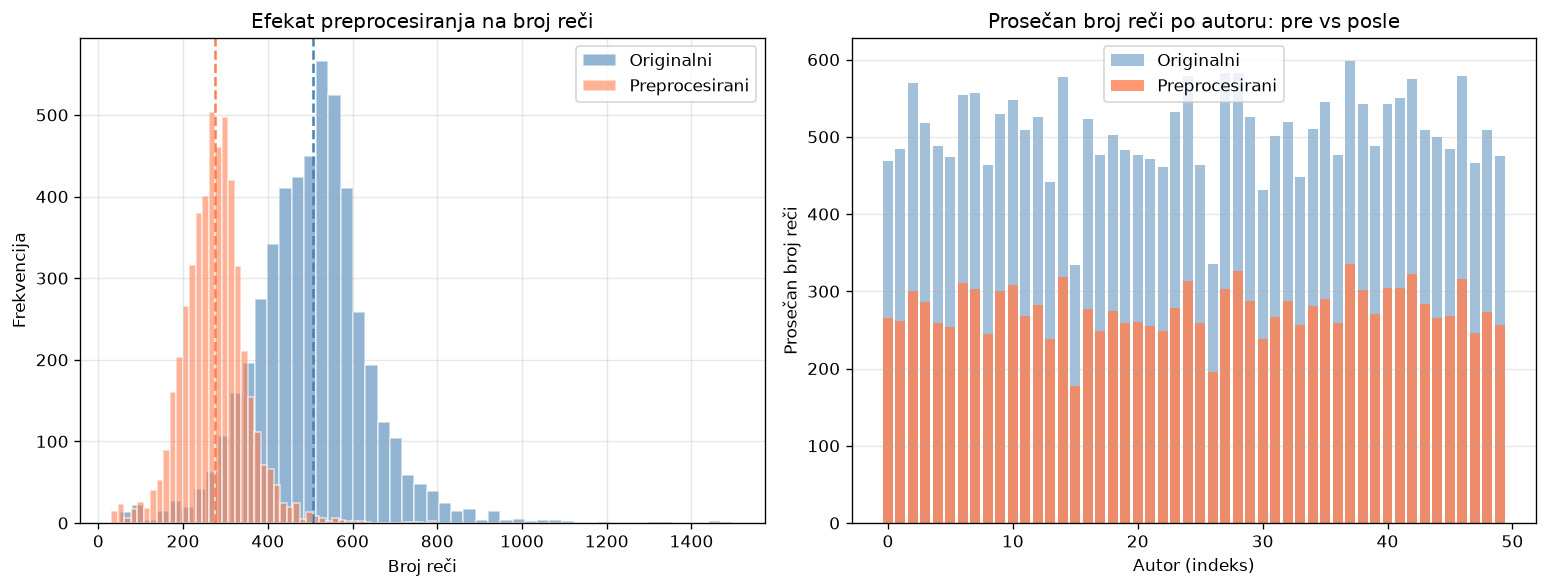

Slika sacuvana: 04_efekat_preprocesiranja.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram: pre vs posle
axes[0].hist(df['word_count'],       bins=50, alpha=0.6, color='steelblue', edgecolor='white', label='Originalni')
axes[0].hist(df['clean_word_count'], bins=50, alpha=0.6, color='coral',     edgecolor='white', label='Preprocesirani')
axes[0].axvline(df['word_count'].mean(),       color='steelblue', linestyle='--', linewidth=1.5)
axes[0].axvline(df['clean_word_count'].mean(), color='coral',     linestyle='--', linewidth=1.5)
axes[0].set_title('Efekat preprocesiranja na broj reči')
axes[0].set_xlabel('Broj reči')
axes[0].set_ylabel('Frekvencija')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bar chart: prosek pre/posle po autoru
avg_before = df.groupby('author')['word_count'].mean()
avg_after  = df.groupby('author')['clean_word_count'].mean()
x = range(len(avg_before))
axes[1].bar(x, avg_before.values, alpha=0.5, color='steelblue', label='Originalni', width=0.8)
axes[1].bar(x, avg_after.values,  alpha=0.8, color='coral',     label='Preprocesirani', width=0.8)
axes[1].set_title('Prosečan broj reči po autoru: pre vs posle')
axes[1].set_xlabel('Autor (indeks)')
axes[1].set_ylabel('Prosečan broj reči')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '04_efekat_preprocesiranja.png'))
plt.show()
print('Slika sacuvana: 04_efekat_preprocesiranja.png')

> **Zaključak:** Histogram jasno prikazuje pomeranje distribucije nalevo nakon preprocesiranja — oba pika su vidljivo odvojena, što vizualno potvrđuje smanjenje od 45.5%. Desni bar chart pokazuje da je efekat preprocesiranja konzistentan kod svih 50 autora — relativni odnosi između autora (ko piše duže, a ko kraće) se čuvaju i nakon preprocesiranja, što znači da stilske karakteristike ostaju.

### Ćelija 5 - Analiza najčešćih reči pre i posle preprocesiranja

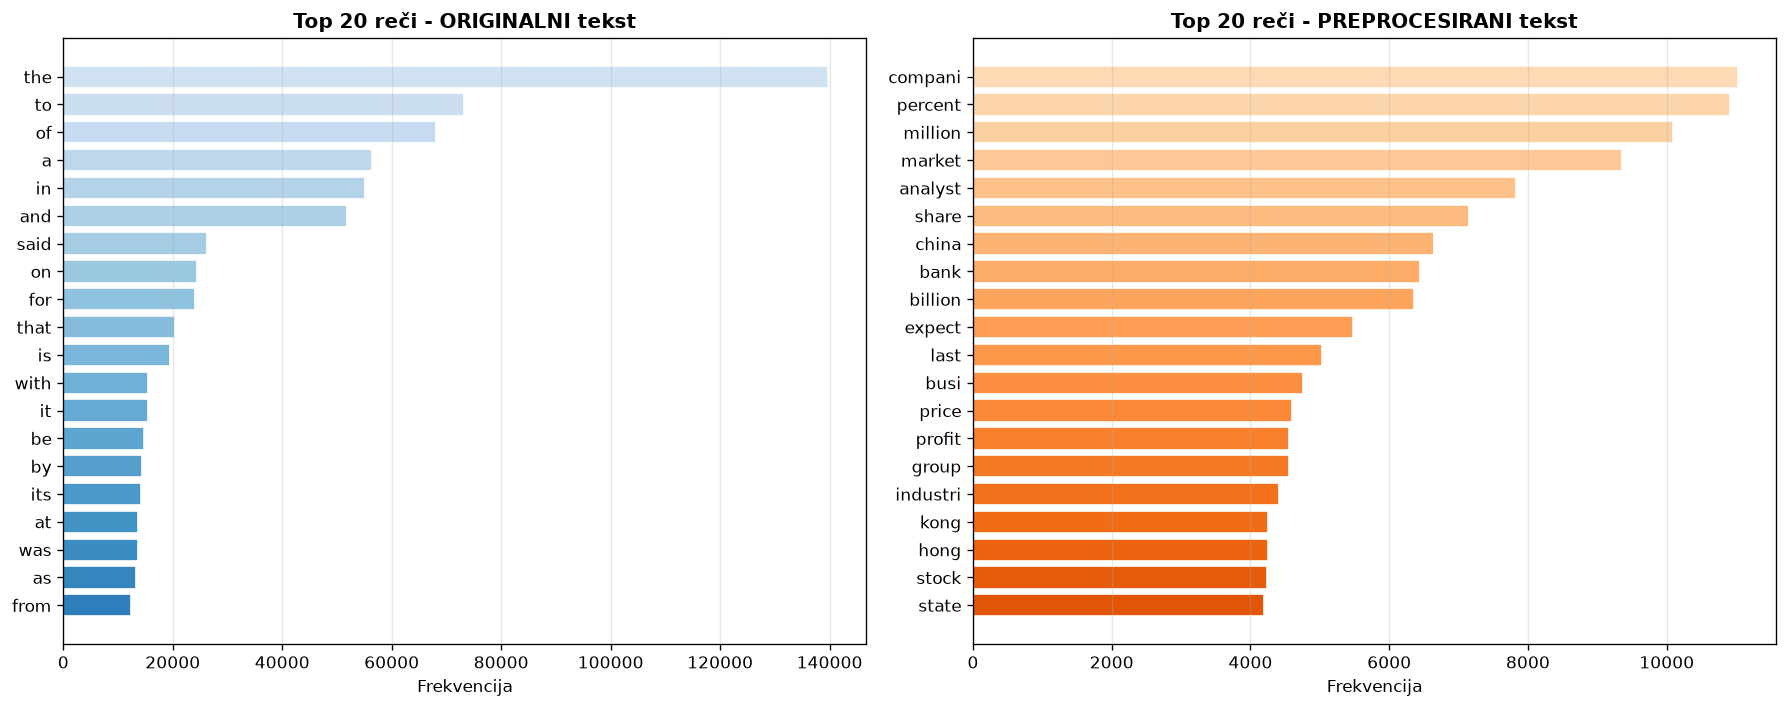

Slika sacuvana: 05_top20_reci_pre_posle.png

Top 20 originalnih reči:
['the', 'to', 'of', 'a', 'in', 'and', 'said', 'on', 'for', 'that', 'is', 'with', 'it', 'be', 'by', 'its', 'at', 'was', 'as', 'from']

Top 20 preprocesiranih reči:
['compani', 'percent', 'million', 'market', 'analyst', 'share', 'china', 'bank', 'billion', 'expect', 'last', 'busi', 'price', 'profit', 'group', 'industri', 'kong', 'hong', 'stock', 'state']


In [6]:
# Top 20 reči u ORIGINALNOM tekstu
raw_words = ' '.join(df['text'].str.lower()).split()
raw_words = [w for w in raw_words if w.isalpha()]
top20_raw  = Counter(raw_words).most_common(20)

# Top 20 reči u PREPROCESIRANOM tekstu
clean_words = ' '.join(df['text_clean']).split()
top20_clean = Counter(clean_words).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

words_r, counts_r = zip(*top20_raw)
axes[0].barh(list(reversed(words_r)), list(reversed(counts_r)),
             color=cm.Blues_r(np.linspace(0.3, 0.8, 20)), edgecolor='white')
axes[0].set_title('Top 20 reči - ORIGINALNI tekst', fontweight='bold')
axes[0].set_xlabel('Frekvencija')
axes[0].grid(axis='x', alpha=0.3)

words_c, counts_c = zip(*top20_clean)
axes[1].barh(list(reversed(words_c)), list(reversed(counts_c)),
             color=cm.Oranges_r(np.linspace(0.3, 0.8, 20)), edgecolor='white')
axes[1].set_title('Top 20 reči - PREPROCESIRANI tekst', fontweight='bold')
axes[1].set_xlabel('Frekvencija')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '05_top20_reci_pre_posle.png'))
plt.show()
print('Slika sacuvana: 05_top20_reci_pre_posle.png')

print('\nTop 20 originalnih reči:')
print([w for w,_ in top20_raw])
print('\nTop 20 preprocesiranih reči:')
print([w for w,_ in top20_clean])

> **Zaključak:** Pre preprocesiranja, top 20 reči su isključivo gramatičke stop-reči (`the`, `to`, `of`, `a`, `in`, `and`, `said`...) koje ne nose semantičku informaciju i bile bi šum u klasifikaciji. Nakon preprocesiranja, top 20 reči su smisleni poslovni i finansijski termini: `compani`, `percent`, `million`, `market`, `analyst`, `share`, `bank`, `billion` — što potvrđuje da je Reuters pre svega agencija za finansijske vesti. Prisustvo `china`, `hong`, `kong` ukazuje na veliku pokrivenost azijskog tržišta u datasetu. Stemovani oblici (`compani` umesto `company`, `industri` umesto `industry`) su ispravno normalizovani.

### Ćelija 6 - Word Cloud

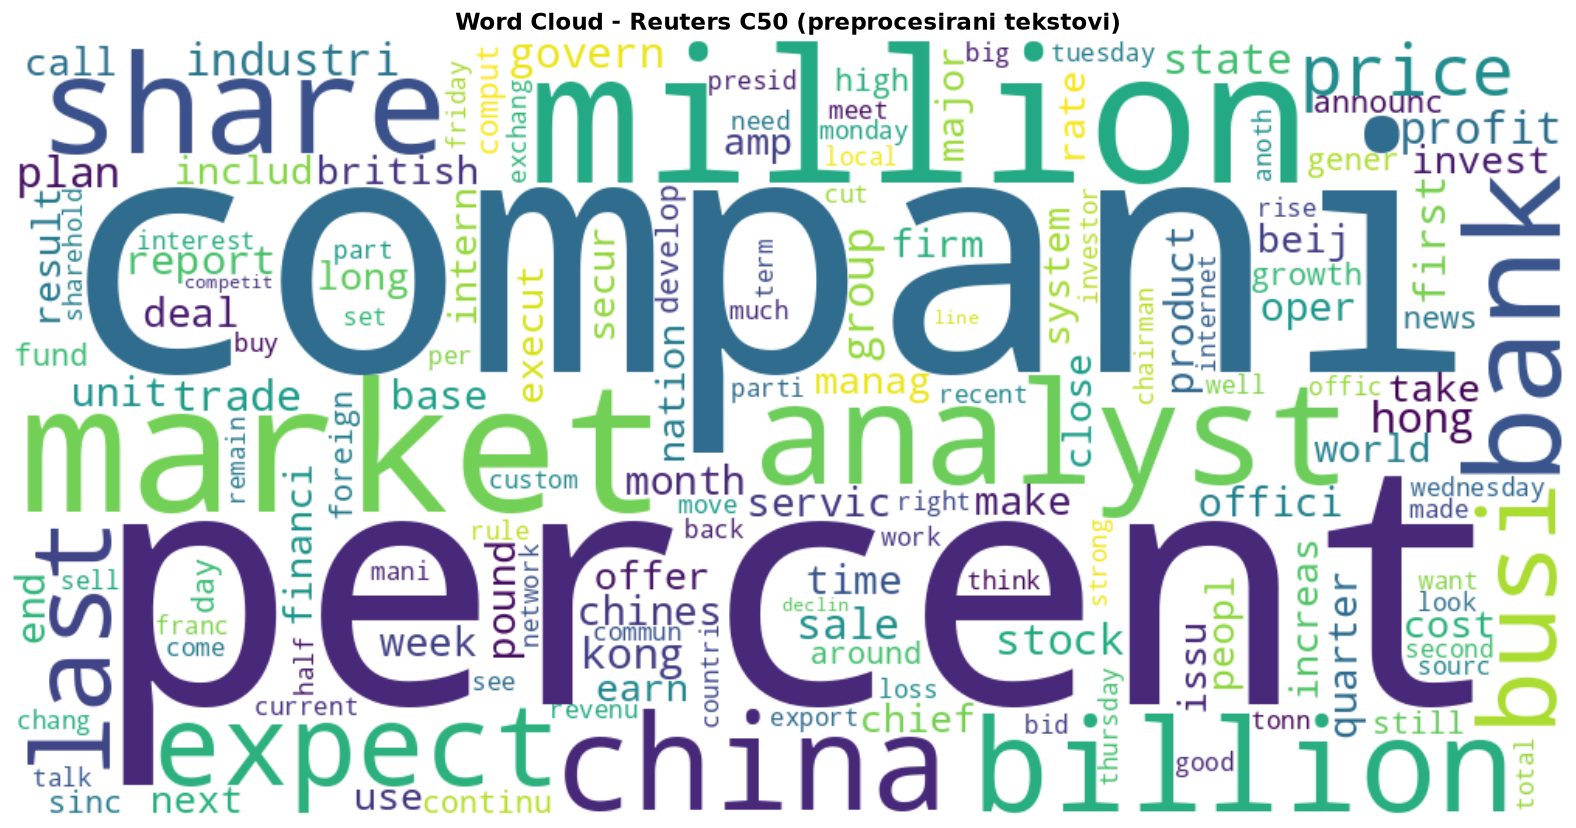

Slika sacuvana: 06_wordcloud.png


In [7]:
from wordcloud import WordCloud

all_clean_text = ' '.join(df['text_clean'].tolist())

wc = WordCloud(
    width=1000, height=500,
    background_color='white',
    colormap='viridis',
    max_words=150,
    collocations=False
).generate(all_clean_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud - Reuters C50 (preprocesirani tekstovi)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '06_wordcloud.png'))
plt.show()
print('Slika sacuvana: 06_wordcloud.png')

> **Zaključak:** Word Cloud vizuelno potvrđuje dominantne teme u datasetu: `compani`, `market`, `percent`, `share`, `bank`, `price`, `china` su prikazane najvećim fontom kao najfrekventnije reči. Ovo odgovara tematici Reuters agencije — finansijsko i ekonomsko novinarstvo. Geografska pokrivenost je vidljiva kroz reči `china`, `hong`, `kong`, `state`, što ukazuje na fokus na globalne, naročito azijske ekonomske vesti.

### Ćelija 7 - Čuvanje preprocesiranih podataka

In [8]:
csv_clean = '/home/zagorka/Desktop/ip2Projekat/reuters_preprocessed.csv'
df[['author','split','filename','word_count','clean_word_count','text_clean']].to_csv(csv_clean, index=False)

print(f'Preprocesirani podaci sačuvani: {csv_clean}')
print(f'Dimenzije: {df[["author","split","filename","word_count","clean_word_count","text_clean"]].shape}')
print()
print('Primer preprocesiranog teksta (prvi dokument):')
print(df['text_clean'].iloc[0][:300])

Preprocesirani podaci sačuvani: /home/zagorka/Desktop/ip2Projekat/reuters_preprocessed.csv
Dimenzije: (5000, 6)

Primer preprocesiranog teksta (prvi dokument):
internet overflow technolog crime cyberspac still old fashion varieti nation consum leagu wednesday popular scam internet pyramid scheme earli investor bogu fund paid deposit later investor leagu non profit consum advocaci group track web scam site set world wide web februari call internet fraud wat


> **Zaključak:** Preprocesirani dataset je sačuvan u `reuters_preprocessed.csv` sa 6 kolona: originalne metainformacije (`author`, `split`, `filename`), statistike dužine (`word_count`, `clean_word_count`) i preprocesirani tekst (`text_clean`). Ovaj fajl se koristi kao polazna tačka za sve naredne korake — TF-IDF vektorizaciju, vizualizaciju i klasifikaciju.